DIPSTICK CALIBRATION:
  50L |  19.46 cm
 100L |  31.30 cm
 150L |  41.49 cm
 200L |  50.81 cm
 250L |  59.60 cm
 300L |  68.03 cm
 350L |  76.21 cm
 400L |  84.23 cm
 450L |  92.14 cm
 500L | 100.00 cm
 550L | 107.86 cm
 600L | 115.77 cm
 650L | 123.79 cm
 700L | 131.97 cm
 750L | 140.40 cm
 800L | 149.19 cm
 850L | 158.51 cm
 900L | 168.70 cm
 950L | 180.54 cm
1000L | 200.00 cm


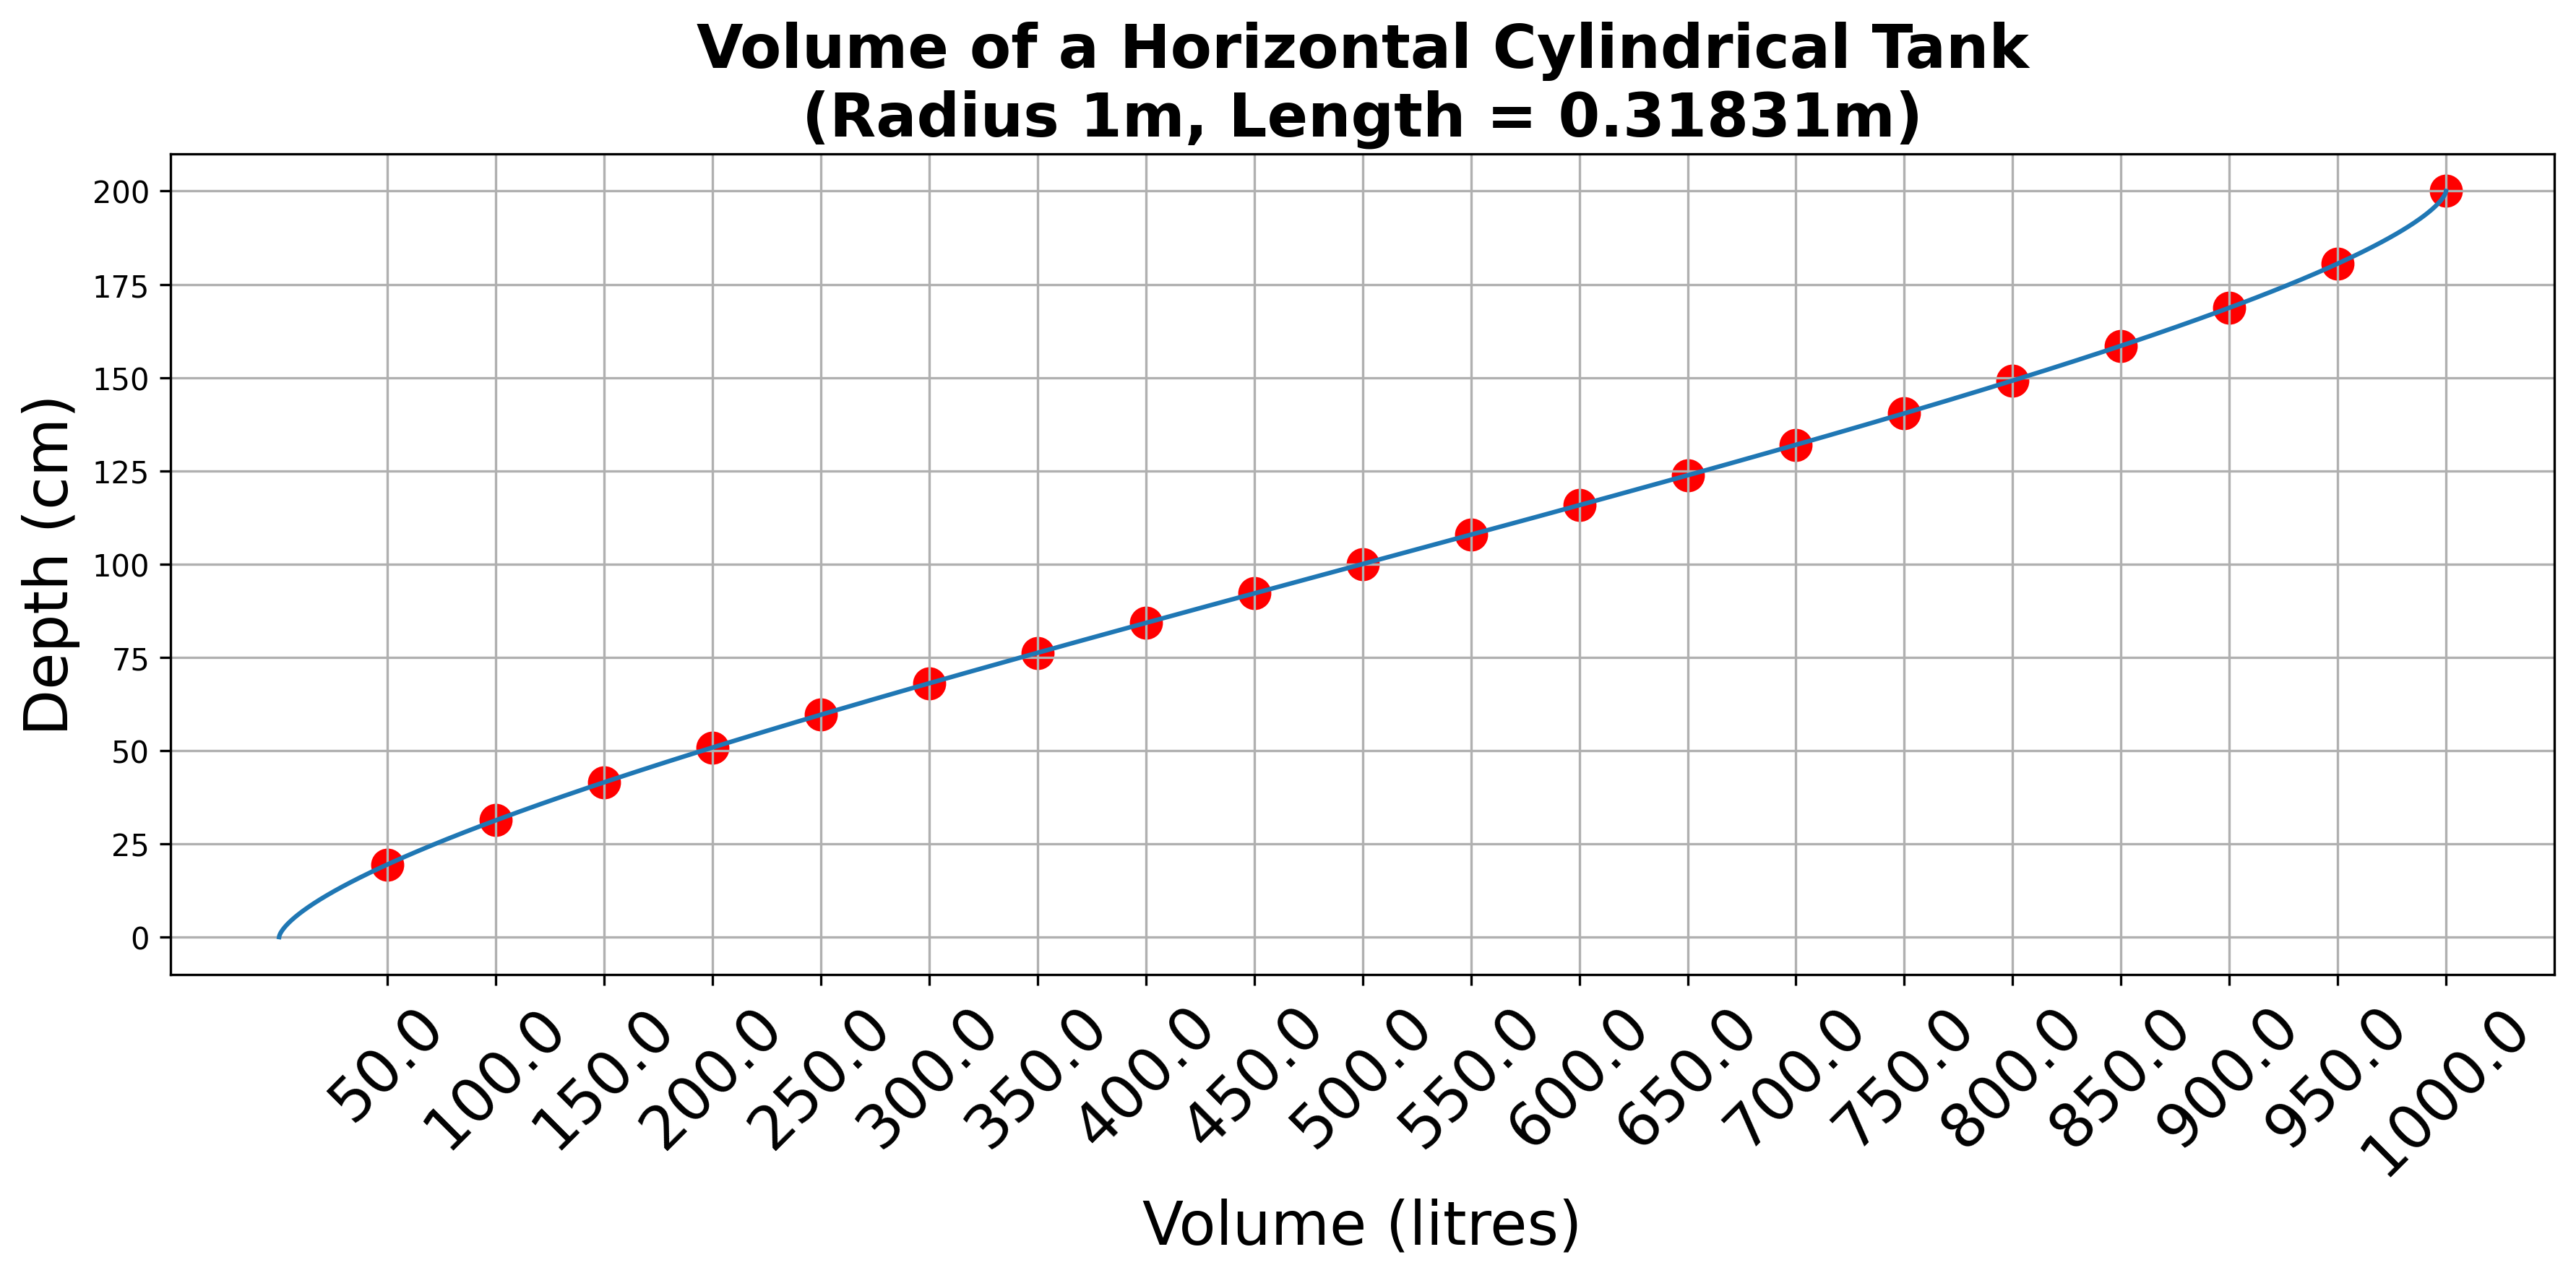

In [7]:
#Dipstick Calibration
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import fsolve
import scipy.stats

n = np.linspace(0.0, 2.0, 1000)
l = 1/np.pi


def volume(h, r, l):

    return (    np.arccos((r-h)/r)*r**2-(((r-h)*np.sqrt(((2*h*r)-h**2)))))*l


a = np.zeros(1000)
for i in range(1000):
    a[i] = volume(n[i], 1, l)

depth_from_volume = interp1d(a, n)




target_volumes = np.arange(50, 1001, 50) / 1000
dipstick_depths = depth_from_volume(target_volumes)

labels=target_volumes*1000
# calibration table
print("DIPSTICK CALIBRATION:")
for vol, depth in zip(range(50, 1001, 50), dipstick_depths):
    print(f"{vol:4}L | {depth*100:6.2f} cm")


plt.figure(figsize=(12, 6), dpi=300)
plt.plot(a*1000,n*100)
plt.scatter( target_volumes*1000,dipstick_depths*100, color='red', s=100)
plt.title(f"Volume of a Horizontal Cylindrical Tank\n(Radius 1m, Length = 0.31831m)",fontsize=20,fontweight='bold')
plt.ylabel('Depth (cm)',fontsize=20)
plt.xlabel('Volume (litres)',fontsize=20)
plt.xticks(target_volumes*1000, labels, rotation=45, fontsize=20)
plt.grid(True, alpha=1.0)
plt.tight_layout()
plt.savefig("dipstick_calibration.pdf", format="pdf")
plt.show()


In [8]:
# Reading error: ±0.5 cm in depth measurement

target_volumes_litres = np.arange(50, 1001, 50)
target_volumes = np.arange(50, 1001, 50) / 1000



reading_error_cm = 0.5
reading_error_m = reading_error_cm / 100


print(f"\nAssuming dipstick reading error of ±{reading_error_cm} cm:\n")
print(f"{'Volume':>10} | {'Depth':>10} | {'ΔV (litres)':>15} | {'% Error':>10}")
print("-" * 52)

volume_errors = []
for vol, depth in zip(target_volumes_litres, dipstick_depths ):
    V_plus = volume(depth + reading_error_m, 1, l) * 1000
    V_minus = volume(depth - reading_error_m, 1, l) * 1000
    error_litres = max(abs(V_plus - vol), abs(V_minus - vol))
    error_percent = (error_litres / vol) * 100
    volume_errors.append(error_litres)
    print(f"{vol:>10.0f}L | {depth*100:>9.2f}cm | ±{error_litres:>12.2f} | {error_percent:>9.2f}%")




Assuming dipstick reading error of ±0.5 cm:

    Volume |      Depth |     ΔV (litres) |    % Error
----------------------------------------------------
        50L |     19.46cm | ±        1.90 |      3.79%
       100L |     31.30cm | ±        2.32 |      2.32%
       150L |     41.49cm | ±        2.59 |      1.72%
       200L |     50.81cm | ±        2.78 |      1.39%
       250L |     59.60cm | ±        2.92 |      1.17%
       300L |     68.03cm | ±        3.02 |      1.01%
       350L |     76.21cm | ±        3.09 |      0.88%
       400L |     84.23cm | ±        3.14 |      0.79%
       450L |     92.14cm | ±        3.17 |      0.71%
       500L |    100.00cm | ±        3.18 |      0.64%
       550L |    107.86cm | ±        3.17 |      0.58%
       600L |    115.77cm | ±        3.14 |      0.52%
       650L |    123.79cm | ±        3.09 |      0.48%
       700L |    131.97cm | ±        3.02 |      0.43%
       750L |    140.40cm | ±        2.92 |      0.39%
       800L |    149.

/tmp/ipython-input-584/2419744736.py:14: RuntimeWarning: invalid value encountered in arccos
  return (    np.arccos((r-h)/r)*r**2-(((r-h)*np.sqrt(((2*h*r)-h**2)))))*l
/tmp/ipython-input-584/2419744736.py:14: RuntimeWarning: invalid value encountered in sqrt
  return (    np.arccos((r-h)/r)*r**2-(((r-h)*np.sqrt(((2*h*r)-h**2)))))*l


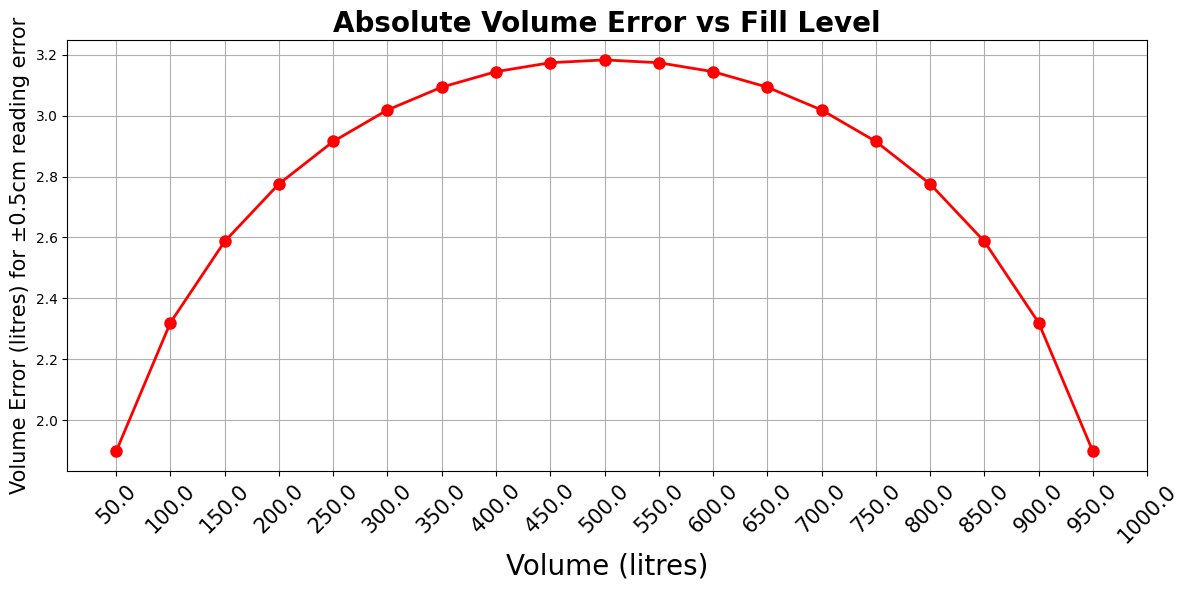

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(target_volumes_litres, volume_errors, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Volume (litres)', fontsize=20)
plt.ylabel('Volume Error (litres) for ±0.5cm reading error', fontsize=15)
plt.title('Absolute Volume Error vs Fill Level', fontsize=20, fontweight='bold')
plt.xticks(target_volumes*1000, labels, rotation=45, fontsize=15)
plt.grid(True, alpha=1.0)
plt.tight_layout()
plt.savefig("Absolute_Volume_Error.pdf", format="pdf")
plt.show()


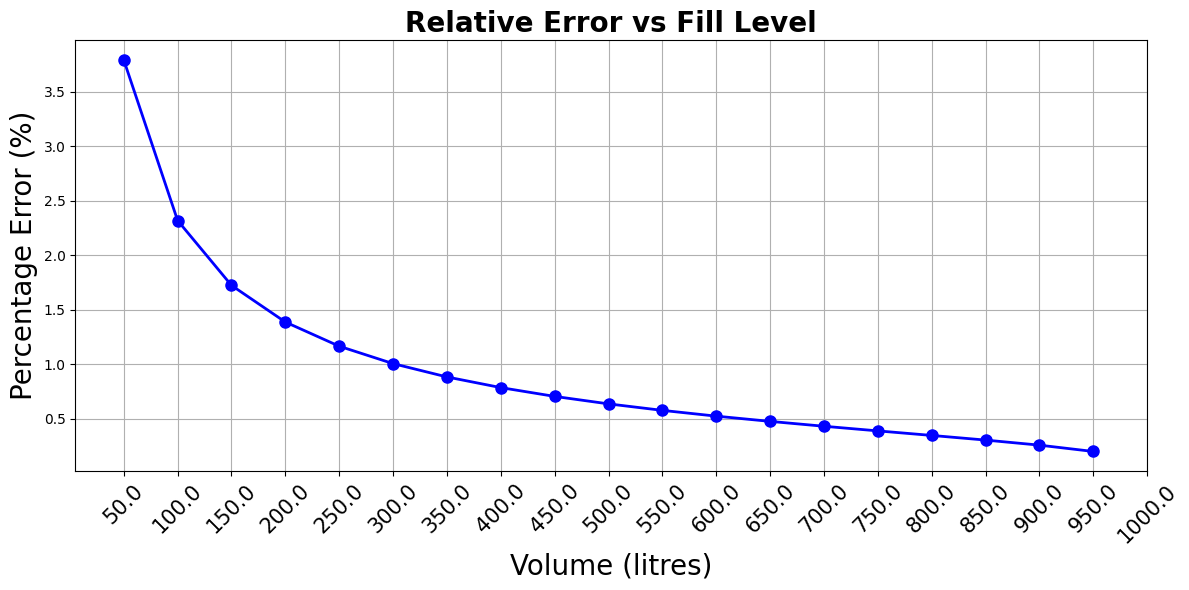

In [13]:
#Relative Error vs Fill Level

plt.figure(figsize=(12, 6))
percentage_errors = [(err/vol)*100 for err, vol in zip(volume_errors, target_volumes_litres)]
plt.plot(target_volumes_litres, percentage_errors, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Volume (litres)', fontsize=20)
plt.xticks(target_volumes*1000, labels, rotation=45, fontsize=15)
plt.ylabel('Percentage Error (%)', fontsize=20)
plt.title('Relative Error vs Fill Level', fontsize=20, fontweight='bold')
plt.grid(True, alpha=1.0)
plt.tight_layout()
plt.savefig("Relative_Error.pdf", format="pdf")
plt.show()


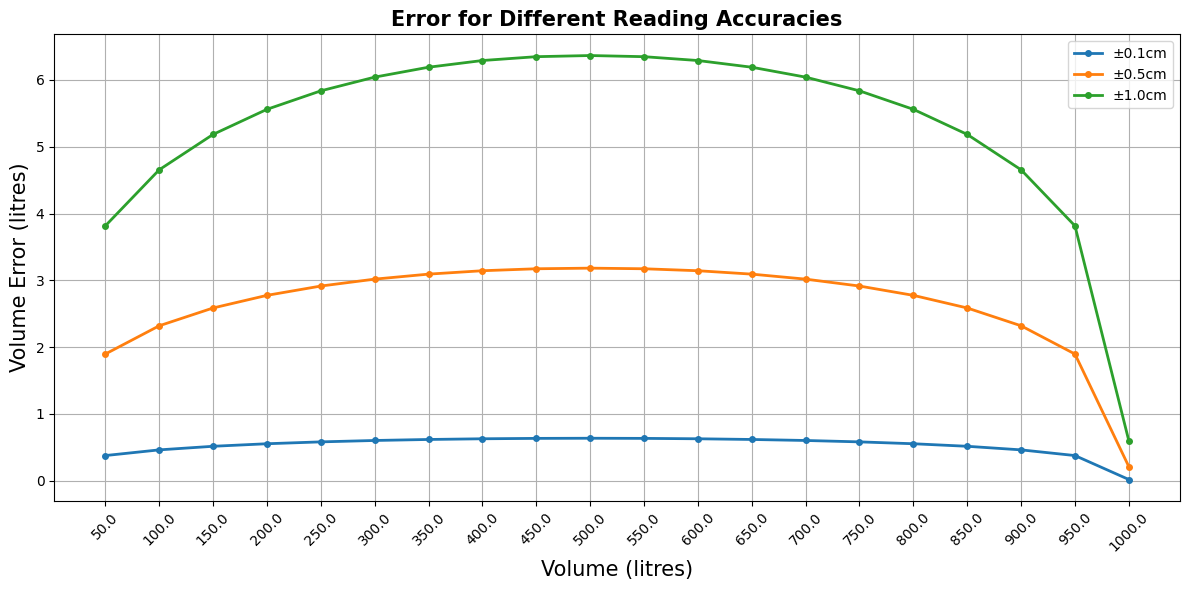

In [14]:
#Error at different reading accuracies

plt.figure(figsize=(12, 6))
plt.xlabel('Volume (litres)', fontsize=15)
plt.ylabel('Volume Error (litres)', fontsize=15)
plt.title('Error for Different Reading Accuracies', fontsize=15, fontweight='bold')

for err_cm in [0.1, 0.5, 1.0]:
    err_m = err_cm / 100
    errors = []
    for vol, depth in zip(target_volumes_litres, dipstick_depths):

        h_plus = np.clip(depth + err_m, 0, 2)
        h_minus = np.clip(depth - err_m, 0, 2)
        V_plus = volume(h_plus, 1, l) * 1000
        V_minus = volume(h_minus, 1, l) * 1000
        error = max(abs(V_plus - vol), abs(V_minus - vol))
        errors.append(error)
    plt.plot(target_volumes_litres, errors, marker='o', linewidth=2,label=f'±{err_cm}cm', markersize=4)

plt.legend(fontsize=10)
plt.xticks(target_volumes*1000, labels, rotation=45, fontsize=10)
plt.grid(True, alpha=1.0)
plt.tight_layout()
plt.savefig("Error_for_Different_Reading_Accuracies.pdf", format="pdf")
plt.show()


In [15]:
#Error rate for multiple readings

import scipy.stats as stats
n_readings = 3

#this simulates a human reading the dipstick accounting for random error in the reading
def simulate_readings(true_depth, n_readings, error_std):
    error_std_m = error_std / 100
    readings = np.random.normal(true_depth, error_std_m, n_readings)
    return readings

#converts the depth into a volume
def calculate_volume_from_readings(depth_readings, r, l):
    volumes = []
    for depth in depth_readings:

        if depth < 0:
            depth = 0
        if depth > 2*r:
            depth = 2*r
        vol = volume(depth, r, l) * 1000  # in litres
        volumes.append(vol)
    return np.array(volumes)


print("\nCOMPARISON: Single Reading vs Multiple Readings (Average)")
print("="*70)

# Run simulation for each calibration mark
np.random.seed(42)  # For reproducibility

single_reading_errors = []
multiple_reading_errors = []
confidence_intervals_95 = []

#finds the error for  a single reading and 5 readings and calculates how wrong it was
for true_vol, true_depth in zip(target_volumes_litres, dipstick_depths):
    # Single reading
    single_depth = simulate_readings(true_depth, 1, reading_error_cm)[0]
    single_volume = calculate_volume_from_readings([single_depth], 1, l)[0]
    single_error = abs(single_volume - true_vol)
    single_reading_errors.append(single_error)

    # Multiple readings (average)
    multiple_depths = simulate_readings(true_depth, n_readings, reading_error_cm)
    average_depth = np.mean(multiple_depths)
    average_volume = calculate_volume_from_readings([average_depth], 1, l)[0]
    multiple_error = abs(average_volume - true_vol)
    multiple_reading_errors.append(multiple_error)

    # Calculate all volumes from multiple readings
    all_volumes = calculate_volume_from_readings(multiple_depths, 1, l)

    # 95% confidence interval
    ci_95 = stats.t.interval(0.95, len(all_volumes)-1,
                              loc=np.mean(all_volumes),
                              scale=stats.sem(all_volumes))
    ci_width = ci_95[1] - ci_95[0]
    confidence_intervals_95.append(ci_width)

print(f"{'Volume':>8} | {'True Depth':>12} | {'Single Error':>13} | {'Avg Error':>11} | {'Improvement':>12}")
print("-"*70)
for i, vol in enumerate(target_volumes_litres):
    improvement = (1 - multiple_reading_errors[i]/single_reading_errors[i]) * 100
    print(f"{vol:>8}L | {dipstick_depths[i]*100:>11.2f}cm | {single_reading_errors[i]:>12.2f}L | {multiple_reading_errors[i]:>10.2f}L | {improvement:>11.1f}%")




COMPARISON: Single Reading vs Multiple Readings (Average)
  Volume |   True Depth |  Single Error |   Avg Error |  Improvement
----------------------------------------------------------------------
      50L |       19.46cm |         0.94L |       1.28L |       -36.5%
     100L |       31.30cm |         0.54L |       1.63L |      -201.5%
     150L |       41.49cm |         1.21L |       0.33L |        72.5%
     200L |       50.81cm |         0.67L |       3.87L |      -477.2%
     250L |       59.60cm |         2.95L |       1.95L |        33.9%
     300L |       68.03cm |         4.43L |       1.59L |        64.1%
     350L |       76.21cm |         1.68L |       0.68L |        59.3%
     400L |       84.23cm |         1.89L |       1.00L |        46.8%
     450L |       92.14cm |         0.04L |       1.54L |     -3494.0%
     500L |      100.00cm |         0.66L |       3.28L |      -393.3%
     550L |      107.86cm |         2.34L |       0.26L |        88.9%
     600L |      115

/tmp/ipython-input-584/680970940.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  improvement = (1 - multiple_reading_errors[i]/single_reading_errors[i]) * 100


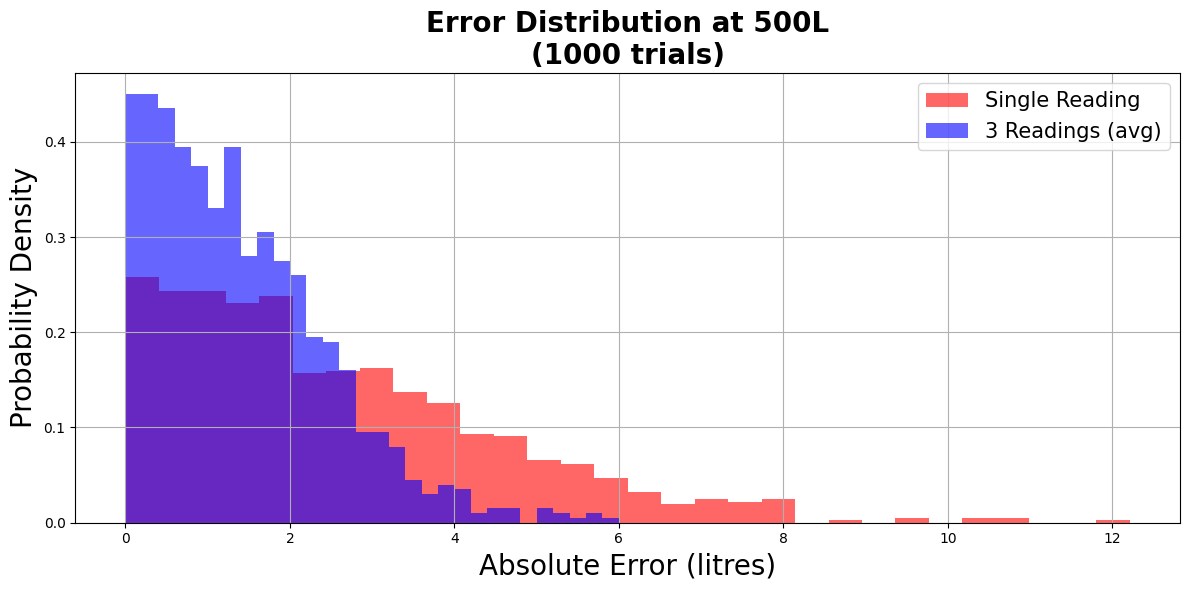

In [18]:
#testing error of 1000 differeent simulations at 500L

plt.figure(figsize=(12, 6))
n_trials = 1000
single_errors_all_trials = []
multiple_errors_all_trials = []


test_volume = 500
test_depth = dipstick_depths[np.where(target_volumes_litres == test_volume)[0][0]]



#repeats above 1000 times and averages them
for trial in range(n_trials):
    # Single reading
    single_depth = simulate_readings(test_depth, 1, reading_error_cm)[0]
    single_volume = calculate_volume_from_readings([single_depth], 1, l)[0]
    single_error = abs(single_volume - test_volume)
    single_errors_all_trials.append(single_error)

    # Multiple readings
    multiple_depths = simulate_readings(test_depth, n_readings, reading_error_cm)
    average_depth = np.mean(multiple_depths)
    average_volume = calculate_volume_from_readings([average_depth], 1, l)[0]
    multiple_error = abs(average_volume - test_volume)
    multiple_errors_all_trials.append(multiple_error)

plt.hist(single_errors_all_trials, bins=30, alpha=0.6, color='red', label='Single Reading', density=True)
plt.hist(multiple_errors_all_trials, bins=30, alpha=0.6, color='blue', label=f'{n_readings} Readings (avg)', density=True)
plt.xlabel('Absolute Error (litres)', fontsize=20)
plt.ylabel('Probability Density', fontsize=20)
plt.title(f'Error Distribution at {test_volume}L\n({n_trials} trials)', fontsize=20, fontweight='bold')
plt.legend(fontsize=15)
plt.grid(True, alpha=1.0)
plt.tight_layout()
plt.savefig("Error_Distribution.pdf", format="pdf")
plt.show()
